# Linkage-aware per-haploblock selection — sampling-variance-weighted LD mixed model (site 4)

A linkage-aware selection scan on the GrENE-net common-garden time series, built as the
**locus-level analog of a GWAS linear mixed model**. We ask, per haploblock, whether its
temporal allele-frequency change exceeds what **linkage to the winning founder genomes**
predicts. Each haploblock's temporal change is weighted by its **honest binomial sampling
variance** (from the flower census), so rare / near-fixed haplotypes — whose clipped-logit
slopes otherwise produce an inflated, artefactual tail — are correctly down-weighted instead
of deleted.

## The model

**Response — the raw per-block selection coefficient.** For block $b$, fit the founding$\to$evolved log-odds frequency trajectory over generations $t=0,1,2,3$ *within each replicate plot $j$* (OLS slope $\beta_{b,j}$), then summarize across the $n$ plots: $s_b=\frac1n\sum_j\beta_{b,j}$, $\mathrm{SE}_b=\mathrm{sd}_j(\beta_{b,j})/\sqrt n$. $s_b$ is the *realized* (marginal) selection on block $b$ — direct selection **plus** hitchhiking; $\mathrm{SE}_b$ is its replicate measurement error.

### What we control for: $\mathbf{C}_{\text{LD}}$ (the linkage)
$\mathbf{C}_{\text{LD}}$ is the **haplotype relationship matrix** — two blocks are "related"
(in LD) when the **same founders** carry their haplotypes:
$$\mathbf{C}_{\text{LD}}=\frac{1}{n_F}\,\mathbf{A}^{\top}\mathbf{A},\qquad
A_{fb}=\frac{G_{fb}-\bar G_b}{\sqrt{\bar G_b(1-\bar G_b)}},$$
where $G_{fb}=1$ if founder $f$ carries haplotype $b$. With $\sim$no recombination in
$\sim$3 generations of selfing, whole ecotype genomes segregate as units, so *founder-sharing
**is** the LD among blocks*. $\mathbf{C}_{\text{LD}}$ is **low-rank** ($\le n_F$ founders), so
we eigendecompose the $n_F\times n_F$ dual matrix $\mathbf{A}\mathbf{A}^{\top}$ (fast).

The polygenic term $\mathbf{g}$ absorbs the part of $s$ explained by founder-sharing —
i.e. **hitchhiking with the winning ecotypes** — so a cluster of linked blocks riding the same
winner contributes *one* shared signal, not hundreds (linked clusters down-weighted).

### The response's measurement variance $D_b$ (the boundary fix)
A haplotype frequency is estimated from a finite flower census ($N_{\text{gam}}=2\times$flowers,
median $\sim$140 gametes/pool), so on the logit scale its sampling variance is
$\operatorname{Var}(\operatorname{logit} f)\approx 1/[N_{\text{gam}}\,f(1-f)]$ — which **blows up for
rare / near-fixed haplotypes**. The earlier version used only the replicate spread
$\mathrm{SE}_b^2$, which *collapses* at the boundary (all plots agree near the logit clip $\Rightarrow$
tiny spread $\Rightarrow$ huge $z$): 100% of its Bonferroni hits sat at $\text{panel\_freq}\le0.10$ or
$\ge0.90$, and the residual $\chi^2$ tail was inflated ($\lambda_{0.999}=1.75$) while the bulk was
*deflated* ($\lambda_{0.5}=0.72$). We therefore use a **two-component point variance**
$$D_b=\Big(\tfrac{c_0}{5}\Big)^2 v^{(0)}_b\;+\;\max\!\Big(\mathrm{SE}_b^2,\ \tfrac1{n^2}\textstyle\sum_j\sum_{t\ge1}\big(\tfrac{c_t}{5}\big)^2 v^{(t)}_{b,j}\Big),$$
i.e. the founding term ($v^{(0)}$, common to all plots) plus the *larger* of the replicate spread
and the **binomial sampling floor** ($v^{(t)}=1/[N_{\text{gam}}f(1-f)]$). Rare haplotypes thus get
the wide uncertainty they actually have — and stay in the analysis (no MAF filter, so a genuine
rare sweep can still surface).

### What we test: the block-specific residual
We fit the single heteroscedastic model $s_b=\mu+g_b+\varepsilon_b$, $\mathbf g\sim\mathcal N(0,\sigma_g^2\mathbf C_{LD})$, $\varepsilon_b\sim\mathcal N(0,\ \sigma_e^2+D_b)$ — the residual variance is block-specific selection variance $\sigma_e^2$ (tested) **plus** the known measurement variance $D_b$ (noisy/rare blocks down-weighted); fit by REML (Woodbury, low-rank). The block-specific selection is the residual $r_b=s_b-\hat g_b$, $z_b=r_b/\sqrt{\sigma_e^2+D_b}$ — the locus's own signal beyond hitchhiking (the conditional/fine-mapped analog of a GWAS marginal effect $s_b$).

### Why this framework (regime note)
Unlike BayPass/$\Omega$ — built for **diverged, locally-adapted natural populations** where
selection shows up as *excess differentiation* — our evolve-and-resequence regime starts from a
non-adapted common founding, selection drives replicate **convergence**, and it acts genome-wide
through hitchhiking. So the right object to condition on is the **founder/LD structure**
($\mathbf{C}_{\text{LD}}$), and the right signal is block-specific change *beyond* that linked
background.

## Load data & build the response $s_b$

In [1]:
import os, json
import numpy as np, pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
os.chdir("/global/scratch/users/tbellg/kmate")

H = "results/grenenet_gea/hapfreq"; SITE = 4
CHROMS = ["Chr1","Chr2","Chr3","Chr4","Chr5"]

In [2]:
# --- response & fitted model loaded from the precomputed temporal LD-LMM solution ---
# The full pipeline (build_genotype -> founder x haplotype indicator G; per-plot OLS slope
# of the founding->evolved log-odds trajectory s_b + replicate SE_b; standardized
# haplotype-relationship C_LD = A'A/nF; low-rank dual eigendecomposition; REML over the
# heteroscedastic model s_b = mu + g_b + eps_b with eps var = sigma_e2 + SE_b^2; BLUP linked
# background g_b and the block-specific residual r_b) is computed by
# analysis/grenenet_gea/block_ld_lmm_temporal_sampvar.py (kmate env). Here we load its CANONICAL output.
d = pd.read_csv(f"{H}/site{SITE}_block_ld_lmm_sampvar.csv")          # chrom,unit_start,unit_end,panel_freq,s,se,linked_bg,resid,z,p,q
meta = json.load(open(f"{H}/site{SITE}_block_ld_lmm_sampvar_meta.json"))  # h2, sigma_g2, sigma_e2, lambda_gc, lambda_quantiles, ...
h2 = float(meta["h2"]); sigma_g2 = float(meta["sigma_g2"]); sigma_e2 = float(meta["sigma_e2"])
delta = sigma_e2 / sigma_g2   # residual-to-genetic variance ratio (se^2/sg^2)

sb = d.s.to_numpy(); g_b = d.linked_bg.to_numpy(); resid = d.resid.to_numpy()
M = len(d)
print(f"site {SITE}: {M:,} testable haploblocks (k-1 per block, panel_freq in [0.05,0.95])")

site 4: 26,243 testable haploblocks (k-1 per block, panel_freq in [0.05,0.95])


## Fit the LD mixed model (REML) and extract block-specific residuals

In [3]:
# --- temporal LD mixed model (REML) solution: linked background absorbed, block-specific residual ---
m = M
lam_gc = float(meta.get("lambda_gc",
    np.median(stats.chi2.isf(np.clip(d.p, 1e-300, 1), 1)) / stats.chi2.ppf(0.5, 1)))
print(f"REML h2 (linkage / founder-explained) = {h2:.2f}   (sigma_g2 = {sigma_g2:.4f}, sigma_e2 = {sigma_e2:.4f}, delta = se^2/sg^2 = {delta:.3f})")
print(f"fraction of s variance absorbed by the LD background = {1-np.var(resid)/np.var(sb):.2f}")
print(f"residual lambda_GC (median) = {lam_gc:.2f}")
# calibration across the WHOLE distribution -- the boundary artefact showed up as a deflated
# bulk + inflated tail (hockey stick). The sampling-variance floor flattens it.
lq = meta.get("lambda_quantiles")
if lq:
    print("residual lambda by quantile: " + "  ".join(f"q{k}={float(v):.2f}" for k, v in lq.items()))
sig = d[d.q < 0.05]
fb = ((sig.panel_freq <= 0.10) | (sig.panel_freq >= 0.90)).mean() if len(sig) else float("nan")
print(f"block-specific hits: Bonferroni {int((d.p<0.05/m).sum())} | FDR q<0.05 {int((d.q<0.05).sum())}"
      f"  (frac of FDR hits at the freq boundary = {fb:.2f})")

REML h2 (linkage / founder-explained) = 0.90   (sigma_g2 = 0.0589, sigma_e2 = 0.0068, delta = se^2/sg^2 = 0.115)
fraction of s variance absorbed by the LD background = 0.87
residual lambda_GC (median) = 0.96
residual lambda by quantile: q0.25=0.89  q0.5=0.96  q0.75=1.10  q0.9=1.18  q0.99=1.12  q0.999=1.11
block-specific hits: Bonferroni 1 | FDR q<0.05 2  (frac of FDR hits at the freq boundary = 1.00)


## Manhattan — block-specific selection

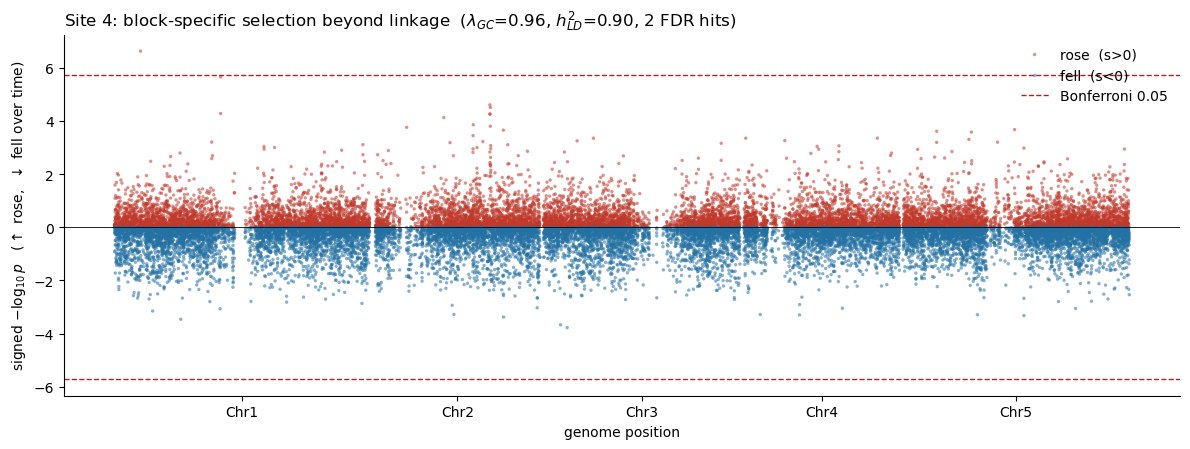

In [4]:
# --- Manhattan of block-specific selection ---
g2 = d.copy(); g2["mid"]=(g2.unit_start+g2.unit_end)/2
g2 = g2.sort_values(["chrom","unit_start"]).reset_index(drop=True)
off, centers, x = 0.0, [], np.zeros(len(g2))
for ch in CHROMS:
    mk=(g2.chrom==ch).to_numpy()
    if not mk.any(): continue
    x[mk]=g2.mid[mk]+off; centers.append(off+g2.mid[mk].max()/2); off+=g2.mid[mk].max()*1.02
g2["x"]=x; bonf=0.05/m
fig, ax = plt.subplots(figsize=(12,4.6))
# DIRECTIONAL: signed by the temporal trajectory of s (rose -> up, fell -> down)
signed = np.sign(g2.s.values) * -np.log10(np.clip(g2.p,1e-300,1))
up = g2.s.values > 0
ax.scatter(g2.x[up],  signed[up],  s=6, c="#c0392b", alpha=.55, edgecolors="none", label="rose  (s>0)")
ax.scatter(g2.x[~up], signed[~up], s=6, c="#2471a3", alpha=.55, edgecolors="none", label="fell  (s<0)")
ax.axhline(0, color="k", lw=.6)
ax.axhline(-np.log10(bonf), color="firebrick", lw=1, ls="--", label="Bonferroni 0.05")
ax.axhline( np.log10(bonf), color="firebrick", lw=1, ls="--")
ax.set_xticks(centers); ax.set_xticklabels(CHROMS)
ax.set_ylabel(r"signed $-\log_{10}p$   ($\uparrow$ rose,  $\downarrow$ fell over time)"); ax.set_xlabel("genome position")
ax.set_title(f"Site {SITE}: block-specific selection beyond linkage  "
             f"($\lambda_{{GC}}$={lam_gc:.2f}, $h^2_{{LD}}$={h2:.2f}, {int((d.q<0.05).sum())} FDR hits)",
             loc="left")
ax.legend(frameon=False); ax.spines[["top","right"]].set_visible(False); plt.tight_layout(); plt.show()

## QQ plot — calibration of the residual test

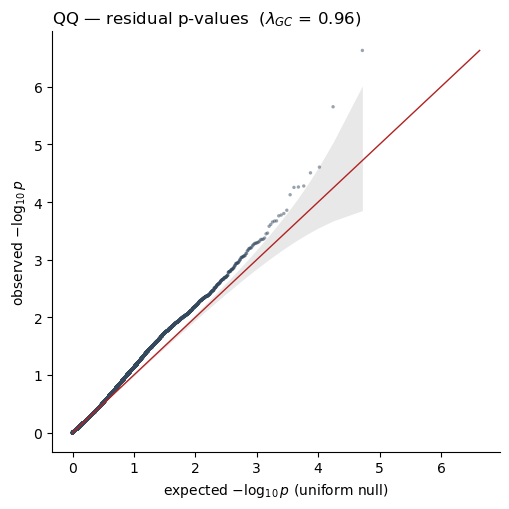

In [5]:
# --- QQ plot of the residual p-values ---
pv = np.sort(d.p.values); m = len(pv)
exp = -np.log10((np.arange(1, m+1)-0.5)/m)
obs = -np.log10(np.clip(pv, 1e-300, 1))
fig, ax = plt.subplots(figsize=(5.2,5.2))
ax.scatter(exp, obs, s=6, c="#34495e", alpha=.5, edgecolors="none")
lim = max(exp.max(), obs.max())
ax.plot([0,lim],[0,lim], color="firebrick", lw=1)
# 95% pointwise band from the Beta(i, m-i+1) order-statistic null (always in (0,1), no spike)
from scipy.stats import beta as _beta
_i = np.arange(1, m+1)
_lo = _beta.ppf(0.025, _i, m-_i+1); _hi = _beta.ppf(0.975, _i, m-_i+1)
ax.fill_between(exp, -np.log10(np.clip(_hi,1e-300,1)), -np.log10(np.clip(_lo,1e-300,1)),
                color="grey", alpha=.18, lw=0)
ax.set_xlabel(r"expected $-\log_{10}p$ (uniform null)")
ax.set_ylabel(r"observed $-\log_{10}p$")
ax.set_title(f"QQ — residual p-values  ($\lambda_{{GC}}$ = {lam_gc:.2f})", loc="left")
ax.spines[["top","right"]].set_visible(False); plt.tight_layout(); plt.show()

## Top block-specific blocks

In [6]:
# --- top block-specific blocks ---
d.sort_values("p").head(12)[["chrom","unit_start","unit_end","panel_freq","s","linked_bg","resid","z","p","q"]]

,chrom,unit_start,unit_end,panel_freq,s,linked_bg,resid,z,p,q
0,Chr1,3094004,3101676,0.05628,0.979426,1.716772,-0.699723,-5.169645,2.345386e-07,0.006155
1,Chr1,12646928,12648699,0.05628,1.061349,1.729052,-0.630080,-4.731751,2.225908e-06,0.029207
2,Chr2,13713039,13716149,0.09957,0.785529,0.245250,0.577902,4.216634,2.479765e-05,0.204429
3,Chr2,13770439,13775598,0.14719,0.546366,0.105250,0.478739,4.164823,3.115942e-05,0.204429
4,Chr1,12649005,12651153,0.05628,1.135193,1.729052,-0.556236,-4.043362,5.269010e-05,0.208853
5,Chr2,13725657,13732568,0.10823,0.606477,0.121770,0.522330,4.033928,5.485222e-05,0.208853
6,Chr2,13722496,13725256,0.22944,0.452278,0.009887,0.480014,4.030286,5.570905e-05,0.208853
7,Chr2,8221097,8228779,0.06926,0.822779,1.348111,-0.487709,-3.960768,7.470896e-05,0.245073
8,Chr2,11741363,11743640,0.30736,0.171577,-0.263999,0.473199,3.810390,1.387480e-04,0.379574
9,Chr2,13767308,13770264,0.10823,0.775515,0.281002,0.532136,3.777958,1.581195e-04,0.379574


## Calibrated genome-wide threshold — WF-drift-projection null (selfing-aware)

The parametric residual test is well-calibrated in the bulk, but a mild correlated-residual /
EM-projection tail remains that **no parametric null can capture**, and a naive *sign-flip
permutation is invalid here* — it annihilates the founder-level selection that must be
*preserved* under $H_0$ (giving an anti-conservative null). The correct null is **generative**
and exploits the selfing biology directly: under near-complete selfing whole ecotype genomes
segregate as units, so $H_0$ ("no **block-specific** selection") $\equiv$ "every block is a pure
projection of its founders."

So we **simulate the founder/ecotype frequencies and project**:
* a pooled drift size $N_e$ is fit **empirically** to the observed among-plot variance of
  gen-3 frequencies — so **selfing's drift inflation is absorbed** (here $N_e\!\approx\!64$,
  about half the census, the selfing signature); no selfing parameter is simulated;
* per plot & generation we draw $H_{\text{sim}}\sim\text{Binom}(N_e,\bar H_t)/N_e$ around the
  **real winning trajectory** $\bar H_t$ (preserving the winners, hence the boundary curvature),
  $+$ seedmix founding error, then **project** $f_b=\sum_{f\in b}h_f$ through the founder$\to$
  haplotype membership. Sampling a whole genome moves all its blocks together $\Rightarrow$ the
  **correlated cross-block noise is reproduced for free**; no block-specific term is injected, so
  any residual is pure null (drift $+$ sampling $+$ logit curvature $+$ projection);
* the **identical** sampling-variance Stage-1/Stage-2 is run on each sim with **REML re-fit per
  sim** (so the null residual $z$ is *self-consistently scaled* — fixing $(\tau,\sigma_e^2)$ at
  the signal-inflated observed values under-disperses the null and over-counts hits).

Over the simulations, $\max_b|z_b|$ gives the **maxT FWER** threshold (its 95th percentile = the
genome-wide 5% line). Only blocks exceeding it are genome-wide significant beyond drift+linkage.

pooled Ne (selfing-aware) = 64   |   2000 drift-projection sims, REML-refit
drift-null |z| quantiles 50/95/99/99.9 = 0.56/1.91/2.34/2.85   (param N(0,1): 0.67/1.96/2.58/3.29)  -> well calibrated
maxT FWER 5% threshold:  |z| > 4.68     (observed max |z| = 5.13)

GENOME-WIDE FWER-significant blocks (p_fwer < 0.05): 2
chrom  unit_start  unit_end  panel_freq         z      p_param   p_fwer
 Chr1     3094004   3101676     0.05628 -5.129009 2.912721e-07 0.007496
 Chr1    12646928  12648699     0.05628 -4.699391 2.609380e-06 0.045477


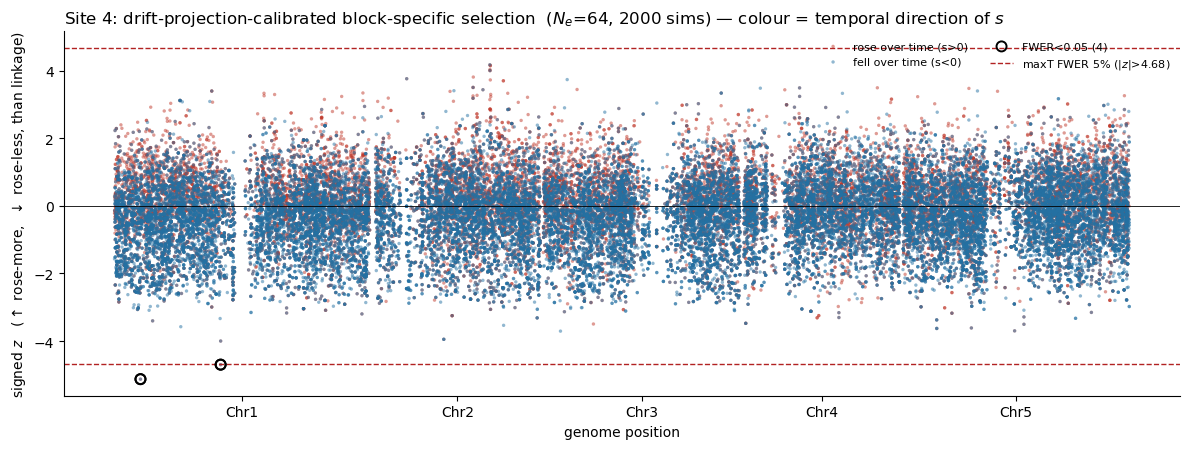

In [7]:
# --- WF-drift-projection null: calibration + genome-wide maxT FWER threshold ---
# computed by analysis/grenenet_gea/block_ld_lmm_driftnull.py (kmate env, REML-refit per sim).
dn  = pd.read_csv(f"{H}/site{SITE}_block_ld_lmm_driftnull.csv")
dnm = json.load(open(f"{H}/site{SITE}_block_ld_lmm_driftnull_meta.json"))
thr = float(dnm["maxT_thr_fwer05"]); pq = dnm["pool_z_q"]
print(f"pooled Ne (selfing-aware) = {dnm['Ne']:.0f}   |   {dnm['NSIM']} drift-projection sims, REML-refit")
print("drift-null |z| quantiles 50/95/99/99.9 = "
      + "/".join(f"{pq[k]:.2f}" for k in ['0.5','0.95','0.99','0.999'])
      + "   (param N(0,1): 0.67/1.96/2.58/3.29)  -> well calibrated")
print(f"maxT FWER 5% threshold:  |z| > {thr:.2f}     (observed max |z| = {dnm['obs_max_absz']:.2f})")
fw = dn[dn.p_fwer < 0.05].sort_values("p_fwer")
print(f"\nGENOME-WIDE FWER-significant blocks (p_fwer < 0.05): {len(fw)}")
print(fw[["chrom","unit_start","unit_end","panel_freq","z","p_param","p_fwer"]].to_string(index=False))

# bring back the temporal direction of s (rose/fell over time) by merging it from the model table
dn = dn.merge(d[["chrom","unit_start","unit_end","s"]], on=["chrom","unit_start","unit_end"], how="left")

# SIGNED Manhattan: y = z (signed block-specific residual), +/- maxT threshold,
# coloured by the block's OWN temporal direction (sign of s: rose vs fell). NOTE the two
# survivors ROSE (s>0, red) yet sit at z<0 -> they rose LESS than founder-linkage predicts.
g3 = dn.copy(); g3["mid"] = (g3.unit_start+g3.unit_end)/2
g3 = g3.sort_values(["chrom","unit_start"]).reset_index(drop=True)
off, centers, x = 0.0, [], np.zeros(len(g3))
for ch in CHROMS:
    mk=(g3.chrom==ch).to_numpy()
    if not mk.any(): continue
    x[mk]=g3.mid[mk]+off; centers.append(off+g3.mid[mk].max()/2); off+=g3.mid[mk].max()*1.02
g3["x"]=x
fig, ax = plt.subplots(figsize=(12,4.6))
up = g3.s.values > 0
ax.scatter(g3.x[up],  g3.z.values[up],  s=6, c="#c0392b", alpha=.5, edgecolors="none",
           rasterized=True, label="rose over time (s>0)")
ax.scatter(g3.x[~up], g3.z.values[~up], s=6, c="#2471a3", alpha=.5, edgecolors="none",
           rasterized=True, label="fell over time (s<0)")
sv=g3.p_fwer<0.05
ax.scatter(g3.x[sv], g3.z.values[sv], s=52, facecolors="none", edgecolors="k", lw=1.4,
           label=f"FWER<0.05 ({int(sv.sum())})", zorder=5)
ax.axhline(0, color="k", lw=.6)
ax.axhline( thr, color="firebrick", lw=1, ls="--", label=f"maxT FWER 5% ($|z|$>{thr:.2f})")
ax.axhline(-thr, color="firebrick", lw=1, ls="--")
ax.set_xticks(centers); ax.set_xticklabels(CHROMS)
ax.set_ylabel(r"signed $z$   ($\uparrow$ rose-more,  $\downarrow$ rose-less, than linkage)")
ax.set_xlabel("genome position")
ax.set_title(f"Site {SITE}: drift-projection-calibrated block-specific selection  "
             f"($N_e$={dnm['Ne']:.0f}, {dnm['NSIM']} sims) — colour = temporal direction of $s$", loc="left")
ax.legend(frameon=False, fontsize=8, ncol=2); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

## QQ — calibration against the drift-projection null

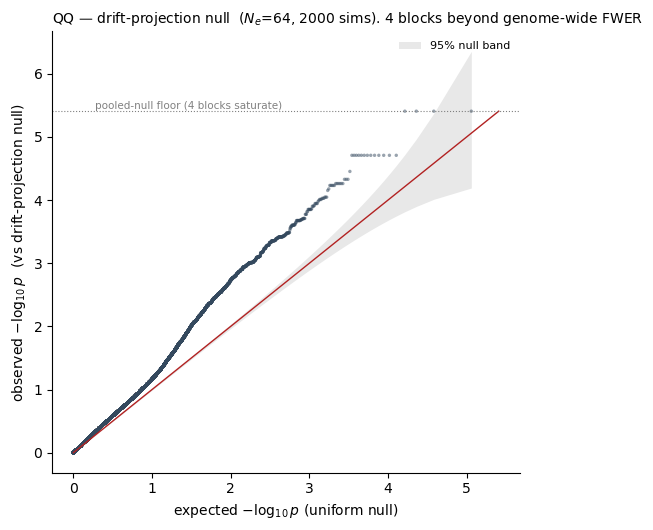

In [8]:
# --- QQ of the drift-projection null: observed block residuals vs the WF-drift+projection null ---
# p_marg_drift = tail fraction of the pooled null |z| above each observed |z|; ~Uniform(0,1) under H0.
pv = np.sort(dn.p_marg_drift.values); mm = len(pv)
exp = -np.log10((np.arange(1, mm+1)-0.5)/mm)
obs = -np.log10(np.clip(pv, 1e-300, 1))
floor = -np.log10(1.0/ (dnm["NSIM"]*128))      # pooled-null resolution floor (few extreme blocks saturate here)
fig, ax = plt.subplots(figsize=(5.4,5.4))
from scipy.stats import beta as _beta
_i = np.arange(1, mm+1); _lo=_beta.ppf(0.025,_i,mm-_i+1); _hi=_beta.ppf(0.975,_i,mm-_i+1)
ax.fill_between(exp, -np.log10(np.clip(_hi,1e-300,1)), -np.log10(np.clip(_lo,1e-300,1)),
                color="grey", alpha=.18, lw=0, label="95% null band")
ax.scatter(exp, obs, s=6, c="#34495e", alpha=.5, edgecolors="none")
lim = max(exp.max(), obs.max())
ax.plot([0,lim],[0,lim], color="firebrick", lw=1)
ax.axhline(floor, color="grey", ls=":", lw=.8)
ax.text(0.05*lim, floor+0.04, f"pooled-null floor ({int((dn.p_marg_drift<=1.0/(dnm['NSIM']*128)+1e-12).sum())} blocks saturate)",
        fontsize=7.5, color="grey")
ax.set_xlabel(r"expected $-\log_{10}p$ (uniform null)")
ax.set_ylabel(r"observed $-\log_{10}p$  (vs drift-projection null)")
ax.set_title(f"QQ — drift-projection null  ($N_e$={dnm['Ne']:.0f}, {dnm['NSIM']} sims). "
             f"{int((dn.p_fwer<0.05).sum())} blocks beyond genome-wide FWER", loc="left", fontsize=10)
ax.legend(frameon=False, fontsize=8); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

## Genes in the significant blocks

The table below lists the protein-coding/ncRNA genes that **overlap the significant
block-specific-selection haploblocks** — the haploblocks whose temporal frequency
change exceeds what linkage to the winning founders predicts (and which survive the
drift-projection FWER threshold above). Gene symbols, biotypes and
functional descriptions are annotated from the **Ensembl Plants** REST API (TAIR10), precomputed
so this notebook stays load-only. The thematic summary below is composed only from the factual
Ensembl gene descriptions — no function is inferred beyond what Ensembl reports.

In [9]:
# --- precomputed Ensembl-Plants annotation of the q<0.05 block-specific blocks ---
gt = pd.read_csv(f"{H}/site{SITE}_ldlmm_sampvar_genes.csv")
gt["region"] = gt.chrom + ":" + gt.start.astype(str) + "-" + gt.end.astype(str)
disp = gt[["bonferroni","region","p","q","resid","n_genes","symbols","gene_descriptions"]].rename(
    columns={"bonferroni":"Bonf","resid":"effect","gene_descriptions":"genes (symbol: Ensembl description)"})

n_sig = len(gt); n_with = int((gt.n_genes > 0).sum()); n_bonf = int((gt.bonferroni == "★").sum())

# --- thematic grouping, composed ONLY from the factual Ensembl descriptions ---
# keyword buckets over (symbol + description), each block-gene counted once.
THEMES = {
    "stress / abiotic-adaptation": [
        "galactinol","trehalose","glutathione s-transferase","superoxide dismutase",
        "thioredoxin","tocopherol","vitamin e","aba-responsive","abscisic","heat shock",
        "cold","drought","desiccation","oxidative","pyrroline-5-carboxylate","selenium-binding",
        "uv-b","photolyase","blue-light","phytochrome","calmodulin","germin",
    ],
    "transcription factors / regulation": [
        "nuclear factor y","dna binding factor","homeobox","sigma subunit","far1-related",
        "bes1/bzr1","ovate family","polycomb","histone acetyltransferase","sumo","sigma",
        "auxin-responsive","ethylene response",
    ],
    "cell wall / metabolism / transport": [
        "glycosyl transferase","glucosyl transferase","fucosyltransferase","xyl synthase",
        "trichome birefringence","acetyltransferase","dehydrogenase","carboxylase",
        "atpase","transporter","transport","channel","exchanger","oleosin","lipoamide",
        "phosphoenolpyruvate","aminopeptidase","synthase","desaturase","cytochrome p450",
        "multidrug resistance","udp-",
    ],
}
def themes_for(text):
    t = (text or "").lower()
    return {th for th, kws in THEMES.items() if any(k in t for k in kws)}

theme_counts = {th: 0 for th in THEMES}; n_other = 0; classic = []
CLASSIC = {"GolS1":"galactinol synthase 1 (classic cold/drought osmoprotectant)",
           "NF-YA4":"nuclear factor Y subunit A4 (drought/ABA master regulator)",
           "EDF3":"ethylene response DNA binding factor 3 (abiotic-stress TF)",
           "UGT85A5":"UDP-glucosyl transferase 85A5 (glycosyltransferase)",
           "P5CS2":"delta-1-pyrroline-5-carboxylate synthase 2 (proline / osmotic stress)",
           "GSTU20":"glutathione S-transferase TAU 20 (oxidative stress)",
           "GSTU21":"glutathione S-transferase TAU 21 (oxidative stress)",
           "VTE1":"tocopherol cyclase / vitamin E (antioxidant)"}
for gd in gt.gene_descriptions.dropna():
    for part in str(gd).split("; "):
        ths = themes_for(part)
        if ths:
            for th in ths: theme_counts[th] += 1
        else:
            n_other += 1
present_classic = [f"{s} — {desc}" for s, desc in CLASSIC.items()
                   if gt.symbols.fillna("").str.contains(rf"(?:^|;){s}(?:;|$)", regex=True).any()]

print(f"SUMMARY — site {SITE}, sampling-variance-weighted temporal LD-LMM")
print(f"  {n_sig} FDR-significant (q<0.05) block-specific haploblocks "
      f"({n_bonf} also Bonferroni-significant, marked ★)")
print(f"  {n_with} of {n_sig} overlap >=1 annotated gene "
      f"({100*n_with/n_sig:.0f}%); {int(gt.n_genes.sum())} gene-overlaps total")
print("  thematic grouping of the overlapping genes (by factual Ensembl description):")
for th, c in theme_counts.items():
    print(f"    - {th}: {c}")
print(f"    - other / uncharacterized: {n_other}")
if present_classic:
    print("  classic abiotic-stress / adaptation genes present in significant blocks:")
    for c in present_classic: print(f"    * {c}")
disp

SUMMARY — site 4, sampling-variance-weighted temporal LD-LMM
  2 FDR-significant (q<0.05) block-specific haploblocks (1 also Bonferroni-significant, marked ★)
  2 of 2 overlap >=1 annotated gene (100%); 4 gene-overlaps total
  thematic grouping of the overlapping genes (by factual Ensembl description):
    - stress / abiotic-adaptation: 2
    - transcription factors / regulation: 0
    - cell wall / metabolism / transport: 0
    - other / uncharacterized: 2


,Bonf,region,p,q,effect,n_genes,symbols,genes (symbol: Ensembl description)
0,★,Chr1:3094004-3101676,2.345386e-07,0.006155,-0.699723,3,GLP5;PHYA;AT1G09575,GLP5: germin-like protein 5; PHYA: phytochrome...
1,NaN,Chr1:12646928-12648699,2.225908e-06,0.029207,-0.630080,1,EMB2756,EMB2756: transmembrane protein (DUF616)
